
# Forecasting the Ideological Makeup of U.S. State Lower Chambers

### Presentation notebook — formulas, methods, and out-of-sample results only

**Data:** Shor–McCarty common-space ideology scores (`np_score`) for state legislators  
**Population:** balanced U.S. state lower chambers, pooled nationally by year  
**Observed sample:** 1998–2020  
**Fit:** 1998–2015  
**Held-out test:** 2016–2020  
**Forecast frequency:** 1 year

We compare three forecasting approaches:

1. **Vanilla Fokker–Planck (non-neural baseline)** — estimate a fixed drift directly from historical densities.
2. **Linear FP / PINN** — learn a fixed drift \(b_\phi(x)\) with a physics-informed neural network.
3. **Proposed nonlinear FP** — let drift depend on the current ideological distribution \(p(t,\cdot)\).

A **persistence** forecast (“the 2015 distribution never changes”) is included only as a sanity benchmark.

> This notebook has the same presentation structure as the Voteview presentation notebook, but all model outputs are re-estimated on Shor–McCarty data.


difference:

|                            |                    **Voteview** |                   **Shor–McCarty** |
| -------------------------- | ------------------------------: | ---------------------------------: |
| Time range used            |                 Congress 79–118 |                          1998–2020 |
| Time points                |               **40 Congresses** |                       **23 years** |
| Institutions               |                **1 U.S. House** | **46 balanced state lower houses** |
| Legislators per time point |                    ~**438–455** |                   ~**5,064–5,111** |
| Total observations used    | ~**17.7k member-Congress obs.** |   **117,092 legislator-year obs.** |
| Ideology variable          |                 `nominate_dim1` |                         `np_score` |
| Ideology range             |             **-1.000 to 0.955** |                **-3.277 to 4.284** |
| Time step                  |                    ~**2 years** |                         **1 year** |
| Model train/test           |                79–110 / 111–118 |              1998–2015 / 2016–2020 |

So the biggest practical difference is:

Voteview = 40 time points × ~440 legislators from one legislature.

Shor–McCarty = 23 time points × ~5,100 legislators pooled from 46 state Houses.


In [2]:

# ============================================================
# COLAB SETUP
# Upload only:
#   national_house_density_1998_2020.csv.gz
# ============================================================
from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.integrate import cumulative_trapezoid

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 17
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_FILE = Path("national_house_density_1998_2020.csv.gz")

if not DATA_FILE.exists():
    try:
        from google.colab import files
        print("Upload: national_house_density_1998_2020.csv.gz")
        uploaded = files.upload()
        names = [n for n in uploaded if n.endswith(".csv.gz")]
        if DATA_FILE.name in uploaded:
            DATA_FILE = Path(DATA_FILE.name)
        elif len(names) == 1:
            DATA_FILE = Path(names[0])
        else:
            raise FileNotFoundError("Upload exactly one .csv.gz file.")
    except ImportError:
        raise FileNotFoundError(
            "Put national_house_density_1998_2020.csv.gz "
            "in the same folder as this notebook."
        )

# Main specification.
DENSITY_COLUMN = "density_legislator_weighted"
# Robustness alternative:
# DENSITY_COLUMN = "density_equal_state_weighted"

TRAIN_END_YEAR = 2015
TEST_START_YEAR = 2016

density_long = pd.read_csv(DATA_FILE)

years = np.sort(density_long["year"].unique()).astype(int)
x_grid = np.sort(density_long["x"].unique()).astype(float)

p_observed = (
    density_long
    .pivot(index="year", columns="x", values=DENSITY_COLUMN)
    .loc[years, x_grid]
    .to_numpy(float)
)

p_observed = np.maximum(p_observed, 0.0)
p_observed /= np.trapezoid(p_observed, x_grid, axis=1)[:, None]

# One unit of t = one calendar year.
t_all = (years - years[0]).astype(float)

train_mask = years <= TRAIN_END_YEAR
test_mask = years >= TEST_START_YEAR

train_years = years[train_mask]
test_years = years[test_mask]
t_train = t_all[train_mask]
t_test = t_all[test_mask]
p_train = p_observed[train_mask]
p_test_observed = p_observed[test_mask]

forecast_start_index = np.where(years == TRAIN_END_YEAR)[0][0]
forecast_start_time = float(t_all[forecast_start_index])
initial_density = p_observed[forecast_start_index].copy()

# ------------------------------------------------------------
# Shared finite-volume solver
# ------------------------------------------------------------
def linear_fp_rhs(density, x_grid, drift, D):
    dx = float(x_grid[1] - x_grid[0])
    b_face = 0.5 * (drift[:-1] + drift[1:])
    p_upwind = np.where(b_face >= 0.0, density[:-1], density[1:])

    flux = np.zeros(len(density) + 1)
    flux[1:-1] = (
        b_face * p_upwind
        - D * (density[1:] - density[:-1]) / dx
    )
    return -(flux[1:] - flux[:-1]) / dx


def advance_linear_fp(
    initial_density,
    start_time,
    target_times,
    x_grid,
    drift,
    D,
    cfl=0.35,
):
    density = np.asarray(initial_density, float).copy()
    density = np.maximum(density, 0.0)
    density /= np.trapezoid(density, x_grid)

    dx = float(x_grid[1] - x_grid[0])
    current_time = float(start_time)
    outputs = []

    max_speed = max(float(np.max(np.abs(drift))), 1e-8)
    rate = max_speed / dx + 2.0 * D / dx**2
    stable_dt = cfl / max(rate, 1e-12)

    for target_time in target_times:
        target_time = float(target_time)

        while current_time < target_time - 1e-12:
            dt = min(stable_dt, target_time - current_time)

            k1 = linear_fp_rhs(density, x_grid, drift, D)
            stage1 = np.maximum(density + dt * k1, 0.0)
            stage1 /= np.trapezoid(stage1, x_grid)

            k2 = linear_fp_rhs(stage1, x_grid, drift, D)
            density = 0.5 * density + 0.5 * (stage1 + dt * k2)
            density = np.maximum(density, 0.0)
            density /= np.trapezoid(density, x_grid)

            current_time += dt

        outputs.append(density.copy())

    return np.vstack(outputs)


def fit_direct_fixed_drift(t_values, x_grid, p_panel, D):
    p_smooth = gaussian_filter(
        p_panel,
        sigma=(0.75, 1.0),
        mode="nearest",
    )
    p_smooth = np.maximum(p_smooth, 0.0)
    p_smooth /= np.trapezoid(
        p_smooth, x_grid, axis=1
    )[:, None]

    p_t = np.gradient(p_smooth, t_values, axis=0, edge_order=2)
    p_x = np.gradient(p_smooth, x_grid, axis=1, edge_order=2)

    integral_pt = cumulative_trapezoid(
        p_t, x_grid, axis=1, initial=0.0
    )

    q = D * p_x - integral_pt
    rho = p_smooth[1:-1]
    q = q[1:-1]

    ridge = 1e-5
    b = (
        np.sum(rho * q, axis=0)
        / (np.sum(rho**2, axis=0) + ridge)
    )

    b = gaussian_filter1d(b, sigma=2.0)
    return np.clip(b, -1.0, 1.0)


# ------------------------------------------------------------
# Select D using TRAINING PERIOD ONLY
# 1998–2012 fit, 2013–2015 validation.
# No 2016–2020 data are used.
# ------------------------------------------------------------
INNER_TRAIN_END = 2012
INNER_VAL_START = 2013
D_CANDIDATES = [0.001, 0.003, 0.01, 0.03]

inner_fit_mask = train_years <= INNER_TRAIN_END
inner_val_mask = train_years >= INNER_VAL_START

d_rows = []

for D_candidate in D_CANDIDATES:
    b_candidate = fit_direct_fixed_drift(
        t_train[inner_fit_mask],
        x_grid,
        p_train[inner_fit_mask],
        D_candidate,
    )

    start_idx = np.where(train_years == INNER_TRAIN_END)[0][0]

    pred = advance_linear_fp(
        initial_density=p_train[start_idx],
        start_time=t_train[start_idx],
        target_times=t_train[inner_val_mask],
        x_grid=x_grid,
        drift=b_candidate,
        D=D_candidate,
    )

    actual = p_train[inner_val_mask]

    d_rows.append([
        D_candidate,
        np.mean((pred - actual) ** 2),
        np.trapezoid(np.abs(pred - actual), x_grid, axis=1).mean(),
    ])

d_selection = pd.DataFrame(
    d_rows,
    columns=["D", "Validation MSE", "Validation IAE"],
)

D = float(
    d_selection.loc[
        d_selection["Validation MSE"].idxmin(),
        "D"
    ]
)

# ------------------------------------------------------------
# PINN helpers
# ------------------------------------------------------------
def to_tensor(array, requires_grad=False):
    return torch.tensor(
        array,
        dtype=torch.float32,
        device=device,
        requires_grad=requires_grad,
    )


def derivative(output, input_tensor):
    return torch.autograd.grad(
        outputs=output,
        inputs=input_tensor,
        grad_outputs=torch.ones_like(output),
        create_graph=True,
        retain_graph=True,
    )[0]


class MLP(nn.Module):
    def __init__(self, input_dim, output_dim=1, width=48, depth=3):
        super().__init__()
        layers = [nn.Linear(input_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, output_dim)]
        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, z):
        return self.net(z)


class DensityNet(nn.Module):
    def __init__(self, t_min, t_max, x_min, x_max):
        super().__init__()
        self.mlp = MLP(2, width=48, depth=3)
        self.t_center = 0.5 * (t_min + t_max)
        self.t_scale = max(0.5 * (t_max - t_min), 1e-6)
        self.x_center = 0.5 * (x_min + x_max)
        self.x_scale = max(0.5 * (x_max - x_min), 1e-6)

    def forward(self, t, x):
        ts = (t - self.t_center) / self.t_scale
        xs = (x - self.x_center) / self.x_scale
        return F.softplus(
            self.mlp(torch.cat([ts, xs], dim=1))
        ) + 1e-7


class DriftNet(nn.Module):
    def __init__(self, x_min, x_max, max_abs_drift=0.5):
        super().__init__()
        self.mlp = MLP(1, width=40, depth=3)
        self.x_center = 0.5 * (x_min + x_max)
        self.x_scale = max(0.5 * (x_max - x_min), 1e-6)
        self.max_abs_drift = float(max_abs_drift)

    def forward(self, x):
        xs = (x - self.x_center) / self.x_scale
        return self.max_abs_drift * torch.tanh(self.mlp(xs))


def compute_fp_terms(density_net, drift_net, t, x, D):
    p = density_net(t, x)
    b = drift_net(x)
    p_t = derivative(p, t)
    p_x = derivative(p, x)
    p_xx = derivative(p_x, x)
    bp_x = derivative(b * p, x)
    residual = p_t + bp_x - D * p_xx
    flux = b * p - D * p_x
    return p, b, residual, flux


def train_linear_pinn(
    t_train,
    x_grid,
    p_train,
    D,
    epochs,
    lr=1e-3,
    n_data=1024,
    n_collocation=768,
    n_boundary=96,
    n_mass_times=6,
):
    t_min, t_max = float(t_train.min()), float(t_train.max())
    x_min, x_max = float(x_grid.min()), float(x_grid.max())

    density_net = DensityNet(t_min, t_max, x_min, x_max).to(device)
    drift_net = DriftNet(x_min, x_max).to(device)

    optimizer = torch.optim.Adam(
        list(density_net.parameters()) + list(drift_net.parameters()),
        lr=lr,
    )

    T, X = np.meshgrid(t_train, x_grid, indexing="ij")
    obs_t = to_tensor(T.reshape(-1, 1))
    obs_x = to_tensor(X.reshape(-1, 1))
    obs_p = to_tensor(p_train.reshape(-1, 1))

    initial_t = to_tensor(np.full((len(x_grid), 1), t_min))
    initial_x = to_tensor(x_grid.reshape(-1, 1))
    initial_p = to_tensor(p_train[0].reshape(-1, 1))

    mass_x = to_tensor(x_grid.reshape(-1, 1))
    dx = float(x_grid[1] - x_grid[0])

    best_loss = np.inf
    best_density = None
    best_drift = None
    n_obs = len(obs_t)

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        idx = np.random.choice(
            n_obs,
            size=min(n_data, n_obs),
            replace=False,
        )

        loss_data = torch.mean(
            (density_net(obs_t[idx], obs_x[idx]) - obs_p[idx]) ** 2
        )

        t_col = (
            t_min + (t_max - t_min)
            * torch.rand(n_collocation, 1, device=device)
        ).requires_grad_(True)

        x_col = (
            x_min + (x_max - x_min)
            * torch.rand(n_collocation, 1, device=device)
        ).requires_grad_(True)

        _, _, residual, _ = compute_fp_terms(
            density_net, drift_net, t_col, x_col, D
        )
        loss_pde = torch.mean(residual ** 2)

        loss_ic = torch.mean(
            (density_net(initial_t, initial_x) - initial_p) ** 2
        )

        bt = (
            t_min + (t_max - t_min)
            * torch.rand(n_boundary, 1, device=device)
        ).requires_grad_(True)

        xl = torch.full(
            (n_boundary, 1), x_min,
            device=device, requires_grad=True
        )
        xr = torch.full(
            (n_boundary, 1), x_max,
            device=device, requires_grad=True
        )

        pl, pr = density_net(bt, xl), density_net(bt, xr)
        bl, br = drift_net(xl), drift_net(xr)
        flux_l = bl * pl - D * derivative(pl, xl)
        flux_r = br * pr - D * derivative(pr, xr)
        loss_bc = torch.mean(flux_l ** 2) + torch.mean(flux_r ** 2)

        mtimes = (
            t_min + (t_max - t_min)
            * torch.rand(n_mass_times, 1, device=device)
        )
        mt = mtimes.repeat_interleave(len(x_grid), dim=0)
        mx = mass_x.repeat(n_mass_times, 1)

        pm = density_net(mt, mx).reshape(n_mass_times, len(x_grid))
        masses = torch.trapezoid(pm, dx=dx, dim=1)
        loss_mass = torch.mean((masses - 1.0) ** 2)

        xs = torch.linspace(
            x_min, x_max, 160, device=device
        ).reshape(-1, 1).requires_grad_(True)

        loss_smooth = torch.mean(
            derivative(drift_net(xs), xs) ** 2
        )

        total = (
            10.0 * loss_data
            + loss_pde
            + 15.0 * loss_ic
            + 5.0 * loss_bc
            + 10.0 * loss_mass
            + 1e-3 * loss_smooth
        )

        total.backward()
        torch.nn.utils.clip_grad_norm_(
            list(density_net.parameters()) + list(drift_net.parameters()),
            20.0,
        )
        optimizer.step()

        value = float(total.detach().cpu())

        if value < best_loss:
            best_loss = value
            best_density = copy.deepcopy(density_net.state_dict())
            best_drift = copy.deepcopy(drift_net.state_dict())

    density_net.load_state_dict(best_density)
    drift_net.load_state_dict(best_drift)
    density_net.eval()
    drift_net.eval()

    return density_net, drift_net


# ------------------------------------------------------------
# Nonlinear model helpers
# ------------------------------------------------------------
def torch_legendre_basis(x_scaled, degree):
    x_scaled = x_scaled.reshape(-1)
    columns = [torch.ones_like(x_scaled)]

    if degree >= 1:
        columns.append(x_scaled)

    for n in range(1, degree):
        columns.append(
            (
                (2*n + 1) * x_scaled * columns[-1]
                - n * columns[-2]
            ) / (n + 1)
        )

    return torch.stack(columns, dim=1)


def central_difference_torch(values, dx):
    out = torch.empty_like(values)
    out[..., 1:-1] = (
        values[..., 2:] - values[..., :-2]
    ) / (2 * dx)
    out[..., 0] = (values[..., 1] - values[..., 0]) / dx
    out[..., -1] = (values[..., -1] - values[..., -2]) / dx
    return out


class NonlinearInteractionFP(nn.Module):
    def __init__(
        self,
        x_grid,
        external_degree=5,
        interaction_scales=(0.15, 0.30, 0.60, 1.20, 2.40),
        max_external_drift=0.5,
        max_kernel_force=0.5,
    ):
        super().__init__()

        x_np = np.asarray(x_grid, dtype=np.float32)
        x_t = torch.tensor(x_np)

        x_center = 0.5 * (x_np.min() + x_np.max())
        x_half = max(0.5 * (x_np.max() - x_np.min()), 1e-6)
        x_scaled = (x_t - x_center) / x_half

        self.register_buffer(
            "external_basis",
            torch_legendre_basis(x_scaled, external_degree),
        )

        r = x_t[:, None] - x_t[None, :]
        kernel_basis = []

        for scale in interaction_scales:
            z = r / float(scale)
            kernel_basis.append(
                z * torch.exp(-0.5 * z**2)
            )

        self.register_buffer(
            "kernel_basis",
            torch.stack(kernel_basis, dim=0),
        )

        self.external_raw = nn.Parameter(
            torch.zeros(external_degree + 1)
        )
        self.kernel_raw = nn.Parameter(
            torch.zeros(len(interaction_scales))
        )

        self.max_external_drift = float(max_external_drift)
        self.max_kernel_force = float(max_kernel_force)

    def external_drift(self):
        raw = self.external_basis @ self.external_raw
        return self.max_external_drift * torch.tanh(raw)

    def kernel_matrix(self):
        raw = torch.einsum(
            "m,mij->ij",
            self.kernel_raw,
            self.kernel_basis,
        )
        return self.max_kernel_force * torch.tanh(raw)

    def drift_from_density(self, density_panel, dx):
        b_ext = self.external_drift()
        K = self.kernel_matrix()
        interaction = (density_panel @ K.T) * dx
        total = b_ext[None, :] + interaction
        return total, b_ext, interaction, K


def train_nonlinear_fp(
    p_train,
    p_t,
    p_x,
    p_xx,
    x_grid,
    D,
    epochs,
    lr=2e-2,
):
    dx = float(x_grid[1] - x_grid[0])
    model = NonlinearInteractionFP(x_grid=x_grid).to(device)

    p_tensor = to_tensor(p_train)
    pt_tensor = to_tensor(p_t)
    px_tensor = to_tensor(p_x)
    pxx_tensor = to_tensor(p_xx)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_loss = np.inf
    best_state = None

    for _ in range(epochs):
        optimizer.zero_grad()

        b, _, _, _ = model.drift_from_density(p_tensor, dx)
        bp_x = central_difference_torch(b * p_tensor, dx)
        residual = pt_tensor + bp_x - D * pxx_tensor

        loss_pde = torch.mean(residual[1:-1] ** 2)

        flux_l = b[:, 0] * p_tensor[:, 0] - D * px_tensor[:, 0]
        flux_r = b[:, -1] * p_tensor[:, -1] - D * px_tensor[:, -1]
        loss_bc = torch.mean(flux_l ** 2) + torch.mean(flux_r ** 2)

        loss_coef = (
            torch.mean(model.external_raw ** 2)
            + torch.mean(model.kernel_raw ** 2)
        )

        total = (
            loss_pde
            + 5.0 * loss_bc
            + 2e-4 * loss_coef
            + 5e-4 * torch.mean(b ** 2)
        )

        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 20.0)
        optimizer.step()

        value = float(total.detach().cpu())

        if value < best_loss:
            best_loss = value
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    return model


def nonlinear_drift_numpy(density, b_external, K, dx):
    return b_external + (K @ density) * dx


def nonlinear_fp_rhs(density, x_grid, b_external, K, D):
    dx = float(x_grid[1] - x_grid[0])
    b = nonlinear_drift_numpy(
        density, b_external, K, dx
    )

    b_face = 0.5 * (b[:-1] + b[1:])
    p_upwind = np.where(
        b_face >= 0.0,
        density[:-1],
        density[1:],
    )

    flux = np.zeros(len(density) + 1)
    flux[1:-1] = (
        b_face * p_upwind
        - D * (density[1:] - density[:-1]) / dx
    )

    return -(flux[1:] - flux[:-1]) / dx, b


def advance_nonlinear_fp(
    initial_density,
    start_time,
    target_times,
    x_grid,
    b_external,
    K,
    D,
    cfl=0.35,
):
    density = np.asarray(initial_density, float).copy()
    density = np.maximum(density, 0.0)
    density /= np.trapezoid(density, x_grid)

    dx = float(x_grid[1] - x_grid[0])
    current_time = float(start_time)
    outputs = []

    for target_time in target_times:
        target_time = float(target_time)

        while current_time < target_time - 1e-12:
            _, b_now = nonlinear_fp_rhs(
                density, x_grid, b_external, K, D
            )

            max_speed = max(
                float(np.max(np.abs(b_now))),
                1e-8,
            )

            stable_dt = 0.35 / max(
                max_speed / dx + 2.0 * D / dx**2,
                1e-12,
            )

            dt = min(stable_dt, target_time - current_time)

            k1, _ = nonlinear_fp_rhs(
                density, x_grid, b_external, K, D
            )

            stage1 = np.maximum(density + dt*k1, 0.0)
            stage1 /= np.trapezoid(stage1, x_grid)

            k2, _ = nonlinear_fp_rhs(
                stage1, x_grid, b_external, K, D
            )

            density = 0.5*density + 0.5*(stage1 + dt*k2)
            density = np.maximum(density, 0.0)
            density /= np.trapezoid(density, x_grid)

            current_time += dt

        outputs.append(density.copy())

    return np.vstack(outputs)


print(
    f"Loaded 1998–2020 | Train 1998–2015 | Test 2016–2020 | "
    f"Selected D={D:g} | Device={device}"
)


Device: cpu
Loaded 1998–2020 | Train 1998–2015 | Test 2016–2020 | Selected D=0.01 | Device=cpu



## Ground truth: annual ideological distribution

For year \(t\), the preprocessed Shor–McCarty data give ideology scores for all active legislators in the balanced state lower-chamber sample.

We convert those member positions into the observed distribution

$$
p_{\mathrm{KDE}}(t,x)
$$

using an ordinary Gaussian KDE on the original Shor–McCarty `np_score` scale.

**Interpretation:** the curve summarizes whether state legislators nationally are concentrated near the center, split into ideological clusters, or shifted toward one side.


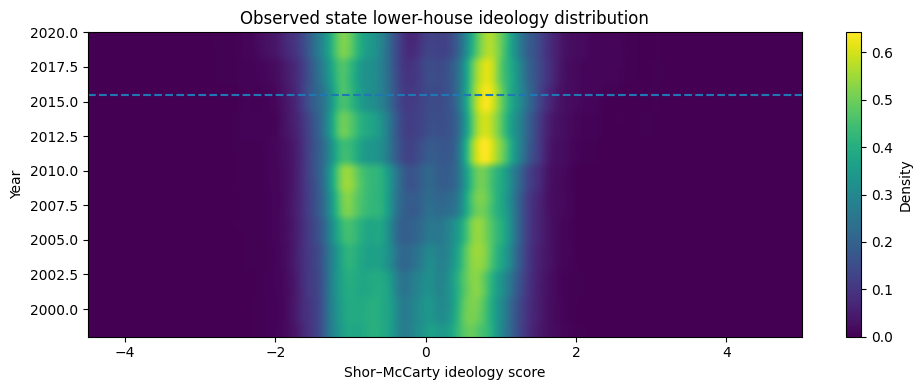

In [ ]:

plt.figure(figsize=(10, 4))
plt.imshow(
    p_observed,
    aspect="auto",
    origin="lower",
    extent=[
        x_grid.min(),
        x_grid.max(),
        years.min(),
        years.max(),
    ],
)
plt.axhline(
    TRAIN_END_YEAR + 0.5,
    linestyle="--",
    linewidth=1.5,
)
plt.xlabel("Shor–McCarty ideology score")
plt.ylabel("Year")
plt.title("Observed ideological distribution over time (KDE)")
plt.colorbar(label="Density")
plt.tight_layout()
plt.show()



# Method 1 — Vanilla Fokker–Planck baseline

The governing equation is

$$
p_t+\partial_x\left(b(x)p\right)-D p_{xx}=0.
$$

With no-flux boundaries, the empirical training densities imply

$$
b(t,x)p(t,x)
=
D p_x(t,x)
-
\int_{x_{\min}}^{x}p_t(t,y)\,dy.
$$

We aggregate this information over the training years to estimate one **time-homogeneous drift**

$$
\hat b_{\mathrm{FPE}}(x),
$$

then solve the PDE forward from the observed 2015 distribution.

**No neural network is used.**


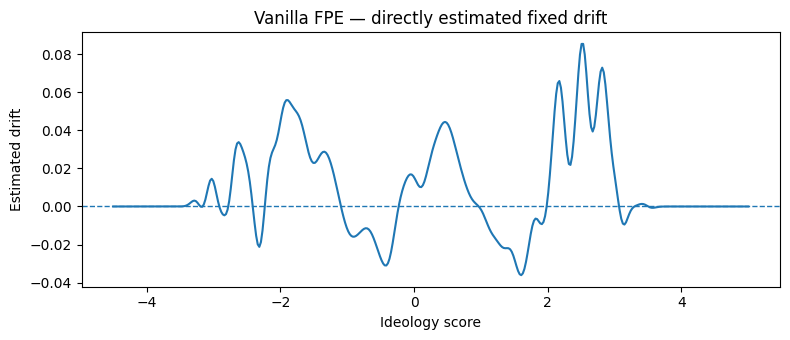

In [ ]:

b_vanilla = fit_direct_fixed_drift(
    t_train,
    x_grid,
    p_train,
    D,
)

p_test_predicted_vanilla = advance_linear_fp(
    initial_density=initial_density,
    start_time=forecast_start_time,
    target_times=t_test,
    x_grid=x_grid,
    drift=b_vanilla,
    D=D,
)

vanilla_mse = np.mean(
    (p_test_predicted_vanilla - p_test_observed) ** 2,
    axis=1,
)

vanilla_iae = np.trapezoid(
    np.abs(p_test_predicted_vanilla - p_test_observed),
    x_grid,
    axis=1,
)

plt.figure(figsize=(8, 3.5))
plt.plot(x_grid, b_vanilla)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Ideology score")
plt.ylabel("Estimated drift")
plt.title("Vanilla FPE — directly estimated fixed drift")
plt.tight_layout()
plt.show()



# Method 2 — Linear Fokker–Planck with PINN

The PDE remains

$$
p_t+\partial_x\left(b_\phi(x)p\right)-D p_{xx}=0.
$$

The difference is that the fixed drift is learned by a neural network:

$$
b_\phi(x)=\mathrm{NN}_\phi(x).
$$

A density network \(p_\theta(t,x)\) is jointly constrained by data fit, the Fokker–Planck residual, the initial condition, no-flux boundaries, probability-mass conservation, and drift smoothness.

After learning \(b_\phi(x)\), the **same finite-volume forward solver** used by the Vanilla FPE forecasts 2016–2020 from the observed 2015 density.


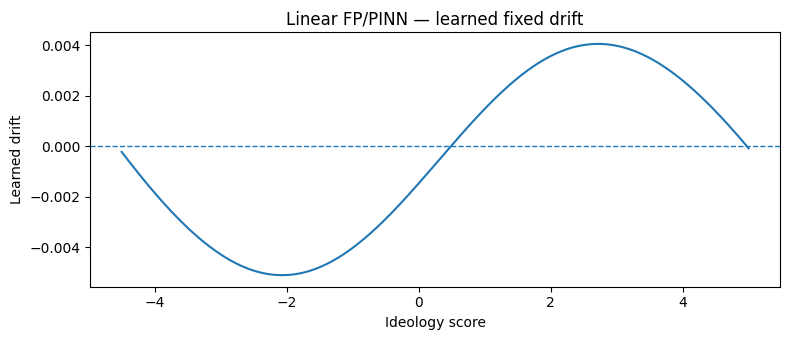

In [ ]:

# Moderate presentation runtime.
# Increase to 2000+ epochs for a final research run on GPU.
LINEAR_PINN_EPOCHS = (
    1200 if device.type == "cuda" else 700
)

density_net, drift_net = train_linear_pinn(
    t_train=t_train,
    x_grid=x_grid,
    p_train=p_train,
    D=D,
    epochs=LINEAR_PINN_EPOCHS,
)

with torch.no_grad():
    learned_b = (
        drift_net(to_tensor(x_grid.reshape(-1, 1)))
        .cpu()
        .numpy()
        .reshape(-1)
    )

p_test_predicted = advance_linear_fp(
    initial_density=initial_density,
    start_time=forecast_start_time,
    target_times=t_test,
    x_grid=x_grid,
    drift=learned_b,
    D=D,
)

linear_pinn_mse = np.mean(
    (p_test_predicted - p_test_observed) ** 2,
    axis=1,
)

linear_pinn_iae = np.trapezoid(
    np.abs(p_test_predicted - p_test_observed),
    x_grid,
    axis=1,
)

plt.figure(figsize=(8, 3.5))
plt.plot(x_grid, learned_b)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Ideology score")
plt.ylabel("Learned drift")
plt.title("Linear FP/PINN — learned fixed drift")
plt.tight_layout()
plt.show()



# Method 3 — Proposed Nonlinear / Nonlocal Fokker–Planck Model

The nonlinear model starts from the same Fokker–Planck framework as the previous two methods, but changes one central assumption:

> **The drift should not be fixed only by ideological position.  
> It should also depend on the current ideological composition of the legislature.**

The derivation below shows how we move from the linear model to the nonlinear model.

---

## Step 1. Start from the standard Fokker–Planck equation

We model the yearly ideology distribution with

$$
p(t,x)
$$

where:

- \(t\) is calendar year,
- \(x\) is ideological position,
- \(p(t,x)\) is the density of legislators around ideological position \(x\) at time \(t\).

The standard Fokker–Planck equation is

$$
p_t
+
\partial_x \bigl( b\,p \bigr)
-
D\,p_{xx}
=
0.
$$

This equation contains two mechanisms.

### Drift

The drift \(b\) determines the systematic direction of movement in ideological space.

If

$$
b(x) > 0,
$$

probability mass tends to move toward larger ideology scores.

If

$$
b(x) < 0,
$$

probability mass tends to move toward smaller ideology scores.

### Diffusion

The diffusion term

$$
D\,p_{xx}
$$

represents random spreading or unexplained dispersion of ideological mass.

---

## Step 2. The linear model assumes a fixed drift

In the Linear FP / PINN model, we assume

$$
b = b(x).
$$

Therefore the PDE is

$$
p_t
+
\partial_x \bigl( b(x)\,p(t,x) \bigr)
-
D\,p_{xx}
=
0.
$$

This means that once we know the ideological position \(x\), the model assigns the same drift regardless of how the rest of the legislature is distributed.

For example, suppose

$$
b(1.0)=0.05.
$$

Then a legislator-density mass near \(x=1.0\) receives the same rightward drift whether:

- the legislature is mostly centrist,
- the legislature is strongly polarized,
- the legislature is concentrated on the left,
- or the legislature is concentrated on the right.

This is the main limitation of the linear model.

The drift is allowed to vary across ideological position, but it does **not** react to the current political environment represented by the distribution \(p(t,x)\).

---

## Step 3. Make the drift depend on the current distribution

To relax this assumption, define the drift as a functional of the current density:

$$
b = b[p](t,x).
$$

Now the drift at ideological position \(x\) can change when the full distribution \(p(t,\cdot)\) changes.

We decompose the drift into two parts:

$$
b[p](t,x)
=
b_{\mathrm{ext}}(x)
+
b_{\mathrm{int}}[p](t,x).
$$

The first part is a persistent background force.

The second part is generated by the current ideological distribution.

---

## Step 4. External drift

The term

$$
b_{\mathrm{ext}}(x)
$$

captures the part of ideological motion that depends only on position \(x\).

It can absorb persistent structural tendencies that are not explicitly modeled through legislator interaction.

Conceptually, it plays the same role as the fixed drift in the linear model.

---

## Step 5. Pairwise ideological interaction

Next, define an interaction function

$$
K(r),
$$

where

$$
r = x-y.
$$

Here:

- \(x\) is the ideological position where we evaluate the force,
- \(y\) is the ideological position of another piece of population mass,
- \(r=x-y\) is their ideological separation.

The function \(K(r)\) describes how ideological mass at \(y\) affects ideological mass at \(x\).

For \(r>0\):

- \(K(r)>0\) acts locally like **repulsion**,
- \(K(r)<0\) acts locally like **attraction**.

The sign reverses when the relative ordering reverses.

That is why the learned interaction kernel is constrained to be approximately odd:

$$
K(-r) \approx -K(r).
$$

---

## Step 6. Aggregate all pairwise interactions

A legislator at position \(x\) is not influenced by only one ideological position \(y\).

The model aggregates the interaction with the entire distribution:

$$
b_{\mathrm{int}}[p](t,x)
=
\int
K(x-y)\,p(t,y)\,dy.
$$

This is a convolution-like interaction term.

The factor

$$
p(t,y)\,dy
$$

represents how much ideological mass is located near \(y\).

Therefore positions with more legislators contribute more strongly to the total interaction force.

---

## Step 7. Final distribution-dependent drift

Combining the external and interaction components gives

$$
b[p](t,x)
=
b_{\mathrm{ext}}(x)
+
\int
K(x-y)\,p(t,y)\,dy.
$$

This is the central modeling change.

The same ideological position \(x\) can now receive different drift in different years because the distribution \(p(t,y)\) changes over time.

So, in general,

$$
b[p_{2000}](x)
\neq
b[p_{2015}](x).
$$

This is what the second nonlinear drift graph is designed to show.

---

## Step 8. Substitute the new drift into the Fokker–Planck equation

Substituting the distribution-dependent drift into the original PDE gives

$$
p_t
+
\partial_x
\left[
p(t,x)
\left(
b_{\mathrm{ext}}(x)
+
\int
K(x-y)\,p(t,y)\,dy
\right)
\right]
-
D\,p_{xx}
=
0.
$$

This is the nonlinear / nonlocal Fokker–Planck equation used in the proposed model.

It is **nonlinear** because the unknown density \(p\) appears both:

1. as the transported quantity, and
2. inside the drift that transports it.

It is **nonlocal** because the drift at position \(x\) depends on the distribution at all other positions \(y\).

---

## Step 9. What the model actually learns

The observed yearly KDE density is treated as fixed training data.

From the training years, the model estimates:

$$
b_{\mathrm{ext}}(x)
$$

and

$$
K(r).
$$

The model chooses these functions so that the observed training densities approximately satisfy

$$
p_t
+
\partial_x \bigl( b[p]\,p \bigr)
-
D\,p_{xx}
\approx
0.
$$

In other words:

> **We observe how the ideology distribution changed historically and infer the interaction law that could have generated those changes.**

---

## Step 10. How external drift is parameterized

For stability and interpretability, we do not use an unrestricted neural network for the external drift.

Instead, it is represented with a low-dimensional smooth basis:

$$
b_{\mathrm{ext}}(x)
=
B_{\max}
\tanh
\left(
\sum_k
c_k P_k(\tilde x)
\right),
$$

where:

- \(P_k\) are Legendre basis functions,
- \(\tilde x\) is the normalized ideological coordinate,
- \(c_k\) are learned coefficients.

This forces the external drift to remain smooth and bounded.

---

## Step 11. How the interaction kernel \(K(r)\) is parameterized

The interaction kernel is also represented with a small smooth basis.

Conceptually,

$$
K(r)
=
K_{\max}
\tanh
\left(
\sum_m
a_m \psi_m(r)
\right),
$$

where each basis function \(\psi_m(r)\) captures interaction at a different ideological distance scale.

The current model uses several scales in raw Shor–McCarty score units.

This gives the model enough flexibility to distinguish:

- short-range interaction,
- medium-range interaction,
- long-range interaction,

while keeping the learned kernel stable and interpretable.

---

## Step 12. Why this model is more structured than simply using a larger neural network

The goal is not only to improve predictive accuracy.

We also want a model that gives a meaningful mechanism.

The linear PINN learns

$$
b(x).
$$

The nonlinear model instead learns the rule

$$
p(t,\cdot)
\longrightarrow
b[p](t,x).
$$

That is, it learns **how the current ideological environment generates the drift**.

This is the main conceptual contribution of the nonlinear formulation.

---

## Step 13. Forward forecasting

After estimating

$$
b_{\mathrm{ext}}(x)
$$

and

$$
K(r)
$$

from the training period, both are frozen.

We then start from the observed 2015 ideology distribution:

$$
p(2015,x).
$$

The nonlinear PDE is solved forward:

$$
p(2015,x)
\rightarrow
\hat p(2016,x)
\rightarrow
\hat p(2017,x)
\rightarrow
\cdots
\rightarrow
\hat p(2020,x).
$$

The actual 2016–2020 distributions are not used to estimate the nonlinear dynamics.

They are used only for out-of-sample evaluation.

---

## Step 14. How to read the two nonlinear graphs

### Graph 1 — Learned pairwise interaction \(K(r)\)

This graph answers:

> **How does ideological separation affect the direction and strength of interaction?**

The x-axis is relative ideological distance

$$
r=x-y.
$$

The y-axis is the learned interaction force \(K(r)\).

The graph is useful for interpreting whether the fitted dynamics look more attraction-like or repulsion-like at different ideological distances.

### Graph 2 — Total drift \(b[p](t,x)\) across years

This graph answers:

> **Does the same ideological position experience different drift when the overall ideological distribution changes?**

If the curves differ across years, then the model is actually using the distribution-dependent interaction term.

That is the direct visual difference from the linear model, where there is only one fixed drift curve \(b(x)\).


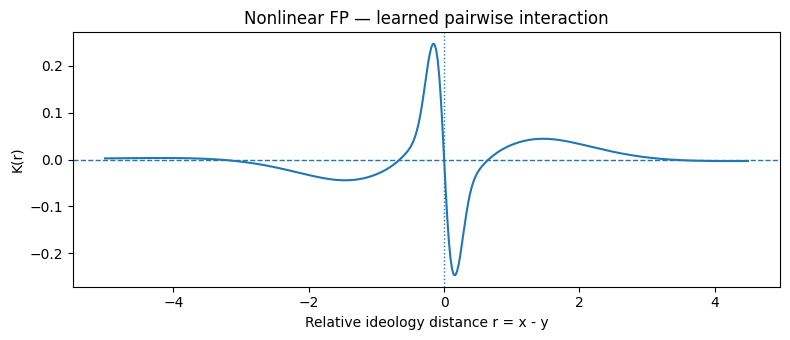

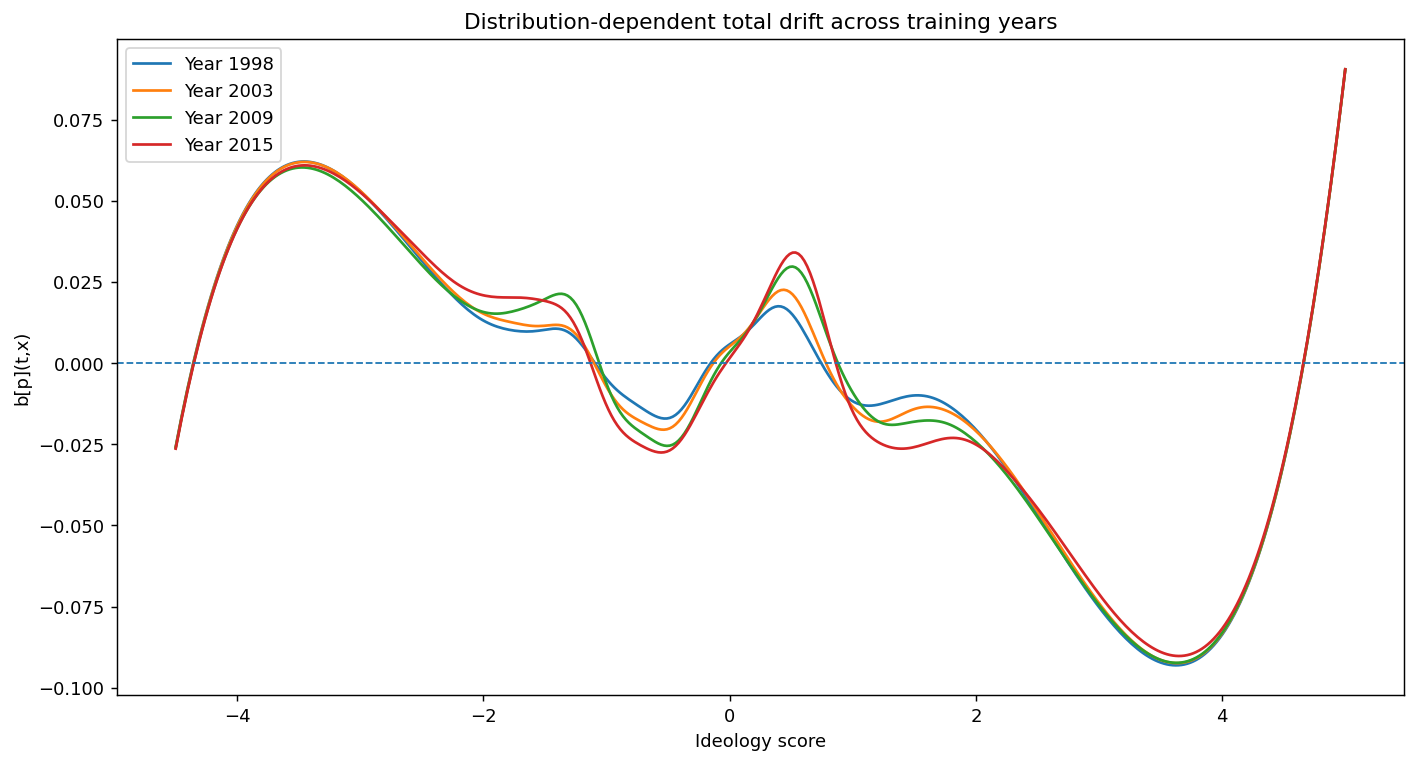

In [ ]:

# Fixed empirical training density for the inverse nonlinear problem.
p_nl_train = gaussian_filter(
    p_train,
    sigma=(0.75, 1.0),
    mode="nearest",
)

p_nl_train = np.maximum(p_nl_train, 0.0)
p_nl_train /= np.trapezoid(
    p_nl_train,
    x_grid,
    axis=1,
)[:, None]

p_nl_t = np.gradient(
    p_nl_train,
    t_train,
    axis=0,
    edge_order=2,
)

p_nl_x = np.gradient(
    p_nl_train,
    x_grid,
    axis=1,
    edge_order=2,
)

p_nl_xx = np.gradient(
    p_nl_x,
    x_grid,
    axis=1,
    edge_order=2,
)

NONLINEAR_EPOCHS = (
    1800 if device.type == "cuda" else 1000
)

nonlinear_fp_model = train_nonlinear_fp(
    p_train=p_nl_train,
    p_t=p_nl_t,
    p_x=p_nl_x,
    p_xx=p_nl_xx,
    x_grid=x_grid,
    D=D,
    epochs=NONLINEAR_EPOCHS,
)

dx = float(x_grid[1] - x_grid[0])

with torch.no_grad():
    (
        b_train_total_t,
        b_external_t,
        b_train_interaction_t,
        kernel_matrix_t,
    ) = nonlinear_fp_model.drift_from_density(
        to_tensor(p_nl_train),
        dx,
    )

b_external = b_external_t.cpu().numpy()
kernel_matrix = kernel_matrix_t.cpu().numpy()
b_train_total = b_train_total_t.cpu().numpy()

# ---- Graph 1: learned K(r)
center_index = int(np.argmin(np.abs(x_grid)))
r_values = x_grid[center_index] - x_grid
K_values = kernel_matrix[center_index]
sort_index = np.argsort(r_values)

plt.figure(figsize=(10, 5))
plt.plot(
    r_values[sort_index],
    K_values[sort_index],
    linewidth=2,
)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(0.0, linestyle=":", linewidth=1)
plt.xlabel("Relative ideological distance r = x - y")
plt.ylabel("K(r)")
plt.title("Learned pairwise ideological interaction force")
plt.tight_layout()
plt.show()

# ---- Graph 2: same nonlinear law produces different drift by year
selected_indices = np.linspace(
    0,
    len(train_years) - 1,
    4,
    dtype=int,
)

plt.figure(figsize=(11, 6))
for idx in selected_indices:
    plt.plot(
        x_grid,
        b_train_total[idx],
        label=f"Year {int(train_years[idx])}",
    )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Ideology score")
plt.ylabel("b[p](t,x)")
plt.title("Distribution-dependent total drift across training years")
plt.legend()
plt.tight_layout()
plt.show()

# OOS nonlinear forecast
p_test_predicted_nonlinear = advance_nonlinear_fp(
    initial_density=initial_density,
    start_time=forecast_start_time,
    target_times=t_test,
    x_grid=x_grid,
    b_external=b_external,
    K=kernel_matrix,
    D=D,
)

nonlinear_test_mse = np.mean(
    (p_test_predicted_nonlinear - p_test_observed) ** 2,
    axis=1,
)

nonlinear_test_iae = np.trapezoid(
    np.abs(p_test_predicted_nonlinear - p_test_observed),
    x_grid,
    axis=1,
)



# Out-of-sample evaluation

Every forecasting method starts from the **same observed 2015 distribution**.

The test years **2016–2020** are never used to fit the dynamics.

### Mean Squared Error (MSE)

$$
\mathrm{MSE}_t
=
\frac{1}{N_x}
\sum_j
\left(
\hat p(t,x_j)
-
p_{\mathrm{KDE}}(t,x_j)
\right)^2
$$

### Integrated Absolute Error (IAE)

$$
\mathrm{IAE}_t
=
\int
\left|
\hat p(t,x)
-
p_{\mathrm{KDE}}(t,x)
\right|
\,dx
$$

**Lower is better for both metrics.**

### Persistence benchmark

Persistence assumes the **2015 distribution never changes** and uses it as the forecast for every year from 2016 through 2020.


In [ ]:

# Persistence benchmark
p_test_persistence = np.repeat(
    initial_density[None, :],
    len(test_years),
    axis=0,
)

persistence_mse = np.mean(
    (p_test_persistence - p_test_observed) ** 2,
    axis=1,
)

persistence_iae = np.trapezoid(
    np.abs(p_test_persistence - p_test_observed),
    x_grid,
    axis=1,
)

comparison = pd.DataFrame({
    "Year": test_years,
    "Vanilla FPE MSE": vanilla_mse,
    "Linear PINN MSE": linear_pinn_mse,
    "Nonlinear FP MSE": nonlinear_test_mse,
    "Persistence MSE": persistence_mse,
    "Vanilla FPE IAE": vanilla_iae,
    "Linear PINN IAE": linear_pinn_iae,
    "Nonlinear FP IAE": nonlinear_test_iae,
    "Persistence IAE": persistence_iae,
})

display(comparison.round(6))

summary = pd.DataFrame({
    "Model": [
        "Vanilla FPE",
        "Linear FP/PINN",
        "Nonlinear FP",
        "Persistence",
    ],
    "Mean OOS MSE": [
        vanilla_mse.mean(),
        linear_pinn_mse.mean(),
        nonlinear_test_mse.mean(),
        persistence_mse.mean(),
    ],
    "Mean OOS IAE": [
        vanilla_iae.mean(),
        linear_pinn_iae.mean(),
        nonlinear_test_iae.mean(),
        persistence_iae.mean(),
    ],
})

p_mse = persistence_mse.mean()
p_iae = persistence_iae.mean()

summary["MSE improvement vs Persistence (%)"] = (
    100
    * (p_mse - summary["Mean OOS MSE"])
    / p_mse
)

summary["IAE improvement vs Persistence (%)"] = (
    100
    * (p_iae - summary["Mean OOS IAE"])
    / p_iae
)

display(summary.round(4))


,Year,Vanilla FPE MSE,Linear PINN MSE,Nonlinear FP MSE,Persistence MSE,Vanilla FPE IAE,Linear PINN IAE,Nonlinear FP IAE,Persistence IAE
0,2016,0.000032,0.000255,0.000073,0.000004,0.026072,0.073194,0.044368,0.010859
1,2017,0.000094,0.000561,0.000192,0.000061,0.050219,0.113108,0.067182,0.043368
2,2018,0.000149,0.001028,0.000262,0.000089,0.061315,0.159588,0.077403,0.050406
3,2019,0.000575,0.002031,0.000628,0.000683,0.131839,0.229307,0.132118,0.141468
4,2020,0.000618,0.002549,0.000687,0.000758,0.139127,0.260913,0.138008,0.149394


,Model,Mean OOS MSE,Mean OOS IAE,MSE improvement vs Persistence (%),IAE improvement vs Persistence (%)
0,Vanilla FPE,0.0003,0.0817,7.9676,-3.3061
1,Linear FP/PINN,0.0013,0.1672,-302.8923,-111.4081
2,Nonlinear FP,0.0004,0.0918,-15.5410,-16.0769
3,Persistence,0.0003,0.0791,0.0000,0.0000


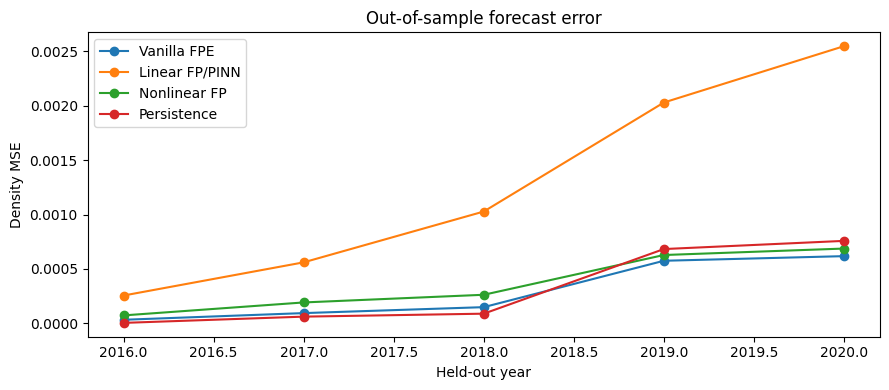

In [ ]:

plt.figure(figsize=(9, 4))

plt.plot(
    test_years,
    persistence_mse,
    marker="o",
    label="Persistence",
)

plt.plot(
    test_years,
    vanilla_mse,
    marker="o",
    label="Vanilla FPE",
)

plt.plot(
    test_years,
    linear_pinn_mse,
    marker="o",
    label="Linear FP/PINN",
)

plt.plot(
    test_years,
    nonlinear_test_mse,
    marker="o",
    label="Nonlinear FP",
)

plt.xlabel("Held-out year")
plt.ylabel("Density MSE")
plt.title("Out-of-sample forecast error by year")
plt.legend()
plt.tight_layout()
plt.show()


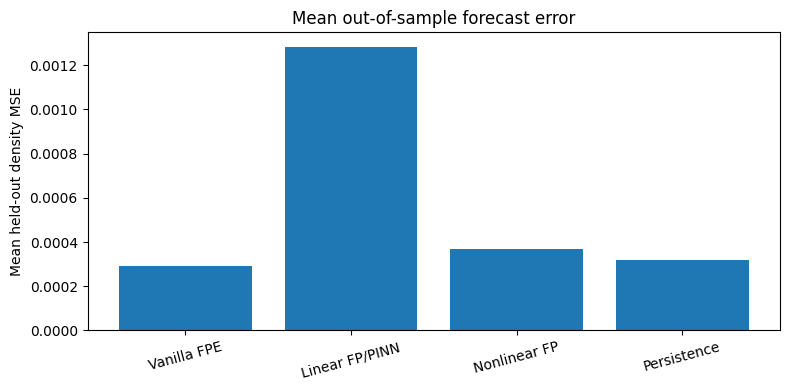

In [ ]:

plt.figure(figsize=(8, 4))

plt.bar(
    summary["Model"],
    summary["Mean OOS MSE"],
)

plt.ylabel("Mean held-out density MSE")
plt.title("Mean out-of-sample forecast error")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



# Current takeaway

Reference run on the Shor–McCarty national pooled lower-house sample:

- **Vanilla FPE:** mean OOS MSE = 0.000293, mean OOS IAE = 0.0817
- **Linear FP/PINN:** mean OOS MSE = 0.001285, mean OOS IAE = 0.1672
- **Nonlinear FP:** mean OOS MSE = 0.000368, mean OOS IAE = 0.0918
- **Persistence:** mean OOS MSE = 0.000319, mean OOS IAE = 0.0791

## Interpretation

On this first Shor–McCarty specification:

- Vanilla FPE has the lowest mean MSE.
- The nonlinear extension is relatively close, but does not yet improve on Vanilla FPE.
- The Linear PINN underperforms on this annual pooled-state dataset.
- Persistence remains surprisingly competitive, particularly under IAE.

The Shor–McCarty data therefore lead to a different empirical result from the earlier Voteview experiment.

The important next step is to use the dataset's unique panel structure:

$$
p_{s,c}(t,x),
$$

where \(s\) denotes state and \(c\) denotes chamber.

That panel design is more natural than pooling every state legislature into one national yearly distribution.
